In [59]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
import scanpy.external as sce
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 10,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/9.17.20_PaperDraft/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(1350, 10) (14714, 2) shape of adata after filtering 


In [67]:
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Experimental_Label_tests.csv', index_col = 0)
TREATMENT_tests = pd.read_csv('../outputs/Treatment_tests.csv', index_col = 0)

clonal_genes = list(CLONE_tests[CLONE_tests.corrected_pvalue < 0.01].gene)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in exp
  result[i] = sum(exp(-energy)*self.weights, axis=0)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scipy/stats/kde.py:261: RuntimeWarning: underflow encountered in multiply
  result[i] = sum(exp(-energy)*self.weights, axis=0)


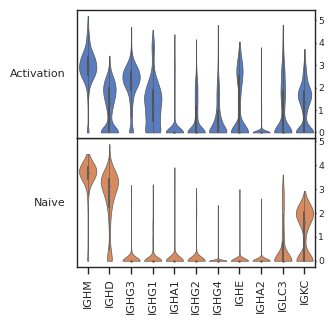

In [61]:
adata.obs['Division_Category'] = adata.obs.Division_Number.astype('category')

IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2', 'IGLC3', 'IGKC']

sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby='Treatment', inner='box', save='TreatmentSwitchTx')

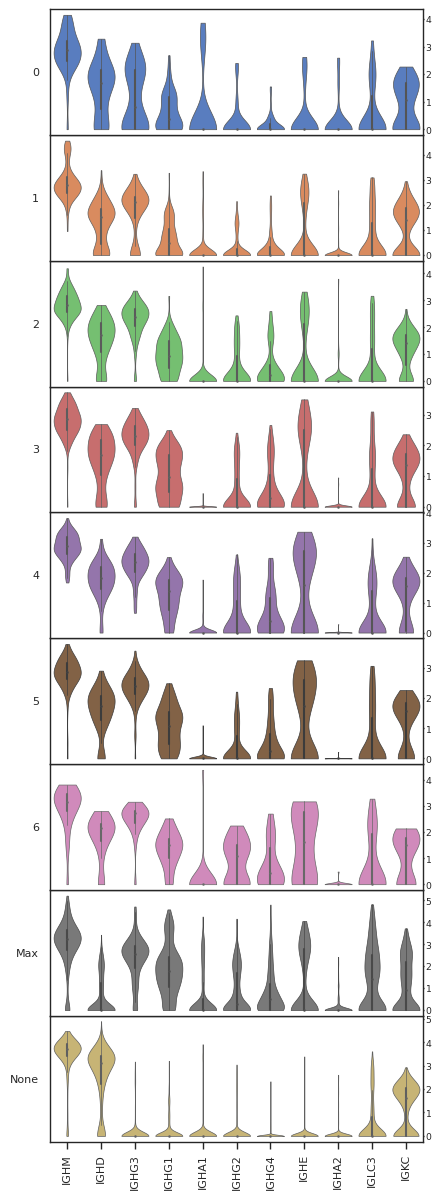

In [62]:
# Filter to no Naive
sc.pl.stacked_violin(adata, var_names = IgH_genes, groupby = 'Division_Category', save='DivisionSwitchTx', inner = 'box',  figsize=[5,15])

In [63]:
sc.tl.dendrogram(adata, groupby='Division_Category', var_names = ['IL4R', 'PRDM1', 'IGHE', 'CD40', 'PAX5'])

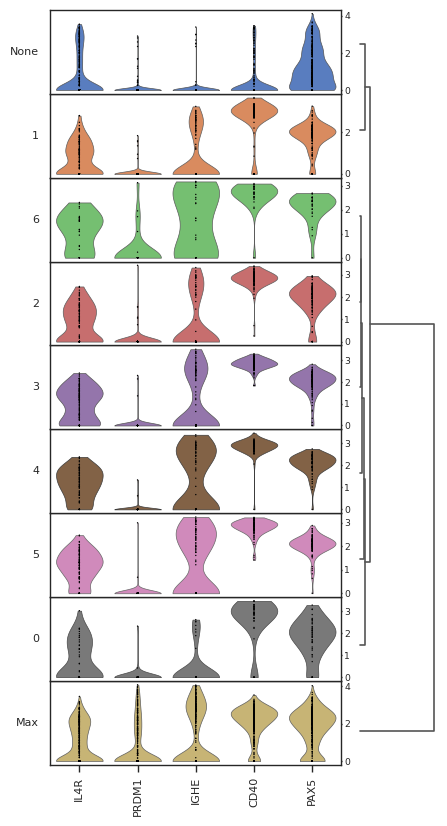

In [64]:
sc.pl.stacked_violin(adata, var_names = ['IL4R', 'PRDM1', 'IGHE', 'CD40', 'PAX5'], groupby='Division_Category', save='BCellGenesByDivision', stripplot=True,figsize=[5,10], dendrogram=True )

In [65]:
sns.set_context('notebook')

In [66]:
def imputeGenes(adata):
    adata_magic = sce.pp.magic(adata, name_list=IgH_genes, knn=5)
    

    array = adata_magic.X

    adata_magic.obs.index

    df = pd.DataFrame(array)

    df.index = adata_magic.obs.index

    df.columns = adata_magic.var.index
    
    return df

In [55]:
def plotPointPlotLocus(IGH_locus_df, cell_list, color):
    """makes a point plot of the IGH locus where reach observation is a cell and an observation consists
    of counts for each of the genes at the IgH locus"""
    sns.set(style = "whitegrid", context = 'paper')
    IGH_locus_df = IGH_locus_df[IGH_locus_df.index.isin(cell_list)]
    ## Point Plot individual clones
    #Data munging
    point_plot_df = IGH_locus_df

    point_plot_df = point_plot_df.reset_index()
    
    point_plot_df = pd.melt(point_plot_df, id_vars = 'cell')
    point_plot_df.columns = ['cell', 'exon', 'log CPM']

    # plotting
    fig, ax = plt.subplots(1, 1, figsize=(12,4))
    sns.set_palette(color)
    sns.pointplot(data = point_plot_df,
                  x = 'exon', y = 'log CPM', hue='cell', dodge =.2,
                  join = True)
    ax.set_ylabel("log CPM")
    ax.set_xlabel("Genes")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    sns.pointplot(data = point_plot_df,
                  x = 'exon', y = 'log CPM', dodge =.2,
                  join = True, linestyles = "--", color = 'k')
    sns.despine()
    ax.set_ylabel("log CPM")
    ax.set_xlabel("Genes")
    sns.set_context("talk")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    sns.set_style("whitegrid", {'axes.grid' : False})
    return fig, ax

In [56]:
df

,IGKC,IGHA2,IGHE,IGHG4,IGHG2,IGHG1,IGHA1,IGHG3,IGHD,IGHM,IGLC3
cell,,,,,,,,,,,
CTY_I8,2.509014,0.074203,3.411405,1.597910,2.258542,3.150743,0.171741,5.884558,3.836601,7.250442,1.409753
MS_SISTER2_J10,2.497874,0.012486,2.588892,1.107474,0.621210,2.099497,0.063554,5.053081,3.698206,6.175679,1.459532
NaiveBcellsplate2_20180629_D23,3.035964,0.076828,0.109344,0.052898,0.315810,0.498193,0.185973,0.417815,6.457882,8.460959,1.138930
NaiveBcellsplate2_20180629_K4,2.334129,0.093829,0.135708,0.028491,0.153579,0.202451,0.193149,0.208351,4.330609,7.099220,1.584495
NaiveBcellsplate2_20180629_P1,2.499041,0.130690,0.097347,0.040647,0.339476,0.408319,0.335654,0.322029,5.986047,8.233994,1.366109
...,...,...,...,...,...,...,...,...,...,...,...
P1_5_23_19_D2_H8,3.661189,0.443627,3.866745,2.260132,3.247281,4.996704,2.570655,5.939775,0.570283,7.532502,4.252416
P1_5_23_19_D2_A19,3.576545,0.422753,3.320397,1.501125,2.084012,4.205477,2.343554,5.590250,0.579842,7.154137,4.211895
P1_5_23_19_D2_M5,4.127485,0.487303,2.193963,1.452940,2.345718,5.451888,2.326225,5.073061,0.243107,7.314063,5.251771


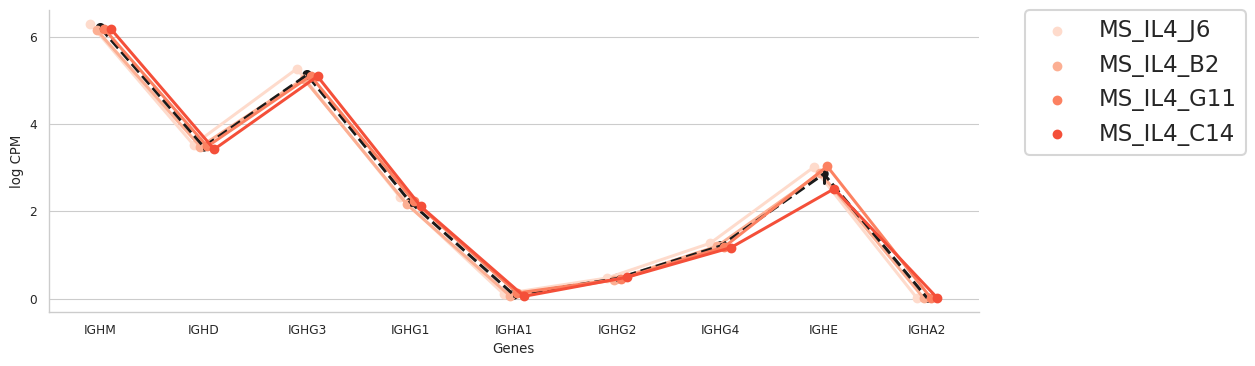

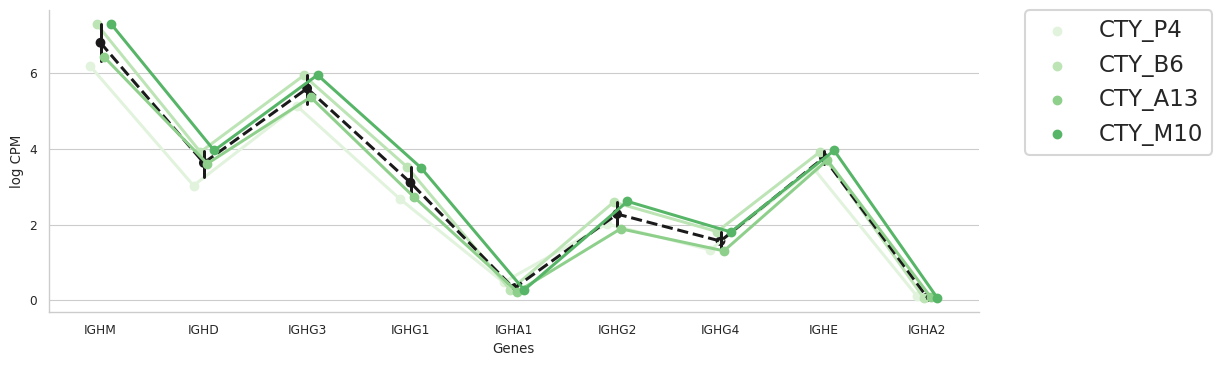

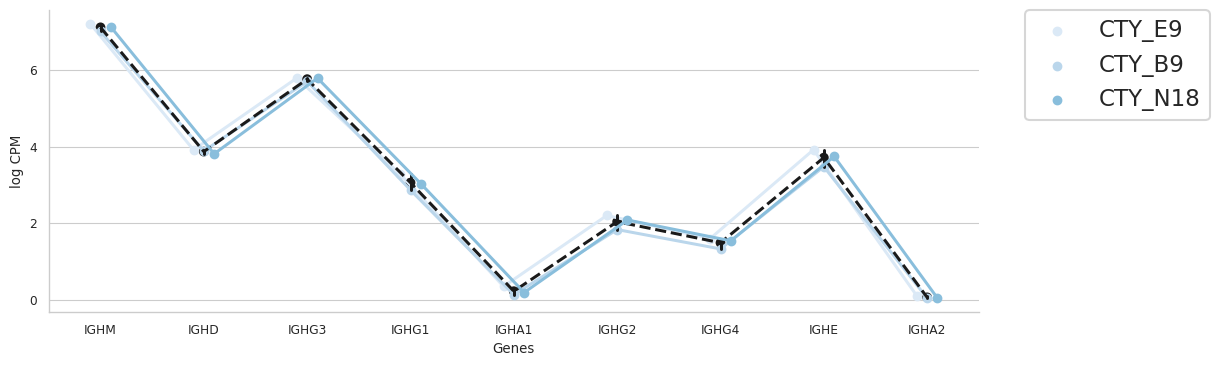

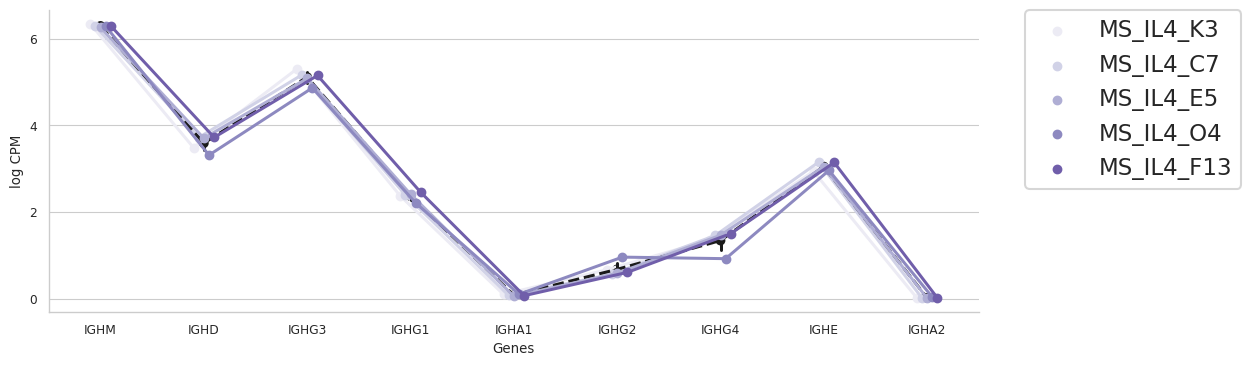

In [57]:
import switchy.util as ut

IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2']

clone = adata.obs.CLONE.value_counts().index[27]
clone2 = adata.obs.CLONE.value_counts().index[34]
clone3 = adata.obs.CLONE.value_counts().index[37]
clone4 = adata.obs.CLONE.value_counts().index[11]

data = df[IgH_genes]
celllist = adata.obs.index[adata.obs.CLONE == clone ]
celllist2 = adata.obs.index[adata.obs.CLONE == clone2]
celllist3 = adata.obs.index[adata.obs.CLONE == clone3]

celllist4 = adata.obs.index[adata.obs.CLONE == clone4]

fig1 , ax1 = plotPointPlotLocus(data, celllist, 'Reds')
fig2, ax2 = plotPointPlotLocus(data, celllist2, 'Greens')
fig3, ax3 = plotPointPlotLocus(data, celllist3, 'Blues')
fig4, ax4 = plotPointPlotLocus(data, celllist4, 'Purples')

In [421]:
## TODO save these as figures
save_figure(fig1, "Lineage1")
save_figure(fig2, "Lineage2")
save_figure(fig3, "Lineage3")
save_figure(fig4, "Lineage4")

# Division Data

In [422]:
divisions = pd.read_csv('ClonalComparison.csv', index_col=0)

In [423]:
def addPearsonofGOIS(df, genelist, divisiondf):
    # Calculate correlation matrix
    #df_corr = pd.DataFrame(np.corrcoef(df[genelist].values), columns=df.index, index = df.index)
    # Use LC to get Pearson for each comparison
    df_corr = df[genelist].T.corr(method = 'spearman')

    result = [df_corr.loc[x,y] for x, y in zip(divisiondf['cell1'], divisiondf['cell2'])]
    divisiondf['Pearson_GeneList'] = result
    return divisiondf

In [442]:
clonal_tests = pd.read_csv('../outputs/CLONE_tests.csv')

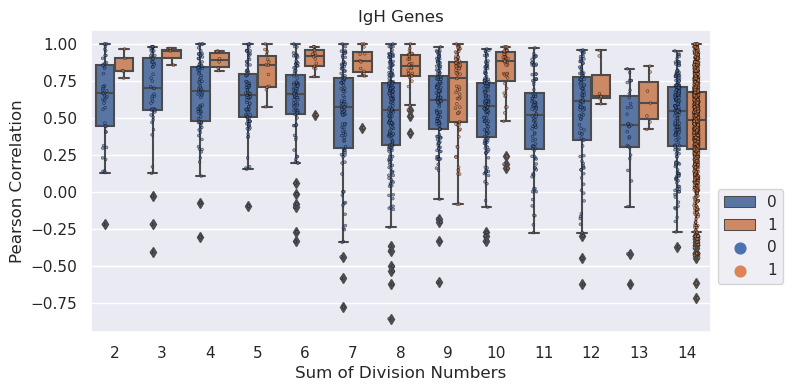

In [425]:
genes = IgH_genes
data = addPearsonofGOIS(df, genes, divisions)

#data = data[data['DivisionSum'] < 100]
data = data[(data['DivisionSum'] < 100) & (data['DivisionSum'] > 1)]

clonal_data = data[data.ClonalBool == 1]
nonclonal_data = data[data.ClonalBool != 1]


downsamples = nonclonal_data.sample(n = 1364)

_data = pd.concat([clonal_data, downsamples])

sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'Pearson_GeneList', hue = 'ClonalBool')

p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.6, edgecolor = 'black', linewidth=0.4, size=2, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Pearson Correlation')
plt.title('IgH Genes')
save_figure(fig, "IgHGenesBoxDivisionClonal")

3507     DDX17
2978    DDX39A
2382        CS
3675       SON
7796    ADAM28
5838    STK17B
1197     PDIA3
6245      CD47
4860    SMCHD1
4565    TRIM22
Name: gene, dtype: object


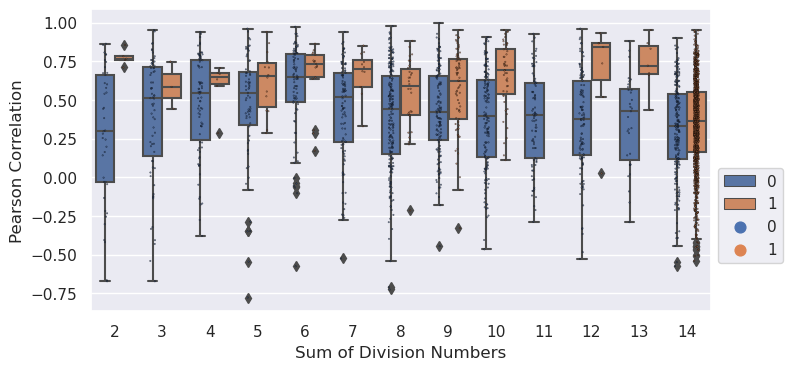

In [426]:
genes = clonal_tests[(clonal_tests.n_cells > 200) & (clonal_tests.means > 3) & (clonal_tests.corrected_pvalue == 1)].sort_values('means', ascending=False)[90:100].gene
data = addPearsonofGOIS(df, genes, divisions)
#Subset to Cells which have divided at least 1
data = data[(data['DivisionSum'] < 100) & (data['DivisionSum'] > 1)]
clonal_data = data[data.ClonalBool == 1]
nonclonal_data = data[data.ClonalBool != 1]

downsamples = nonclonal_data.sample(n = 1364)

_data = pd.concat([clonal_data, downsamples])

sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'Pearson_GeneList', hue = 'ClonalBool')

p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.6, edgecolor = 'black', linewidth=0.4, size=1, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
#ax.legend(labels = ['Clonal', 'Non Clonal'])
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Pearson Correlation')
plt.title('Non Clonal')
print(genes)
save_figure(fig, "NonClonalGenesDivisionBox")

In [449]:
Clonal_Non_Environmental_Genes = ['PRDM1',
 'HOPX',
 'MS4A1',
 'FAM46C',
 'CD38',
 'ACTC1',
 'ZFP57',
 'CKAP4',
 'CLEC2B',
 'HIST1H3G',
 'PDE4D',
 'CEP128',
 'PAX5',
 'CITED2',
 'IQGAP2',
 'ALOX5',
 'TCEAL7',
 'SETBP1',
 'ZFAT',
 'TRAM2',
 'SELPLG',
 'AHNAK',
 'E2F2',
 'COTL1',
 'MYH8',
 'CFI',
 'TP53INP1',
 'TEX261',
 'KCNN3',
 'AC246787.2',
 'DTX1',
 'VRK3',
 'IL13RA1',
 'HIST1H2BC',
 'KCTD10',
 'CIITA',
 'VPS35L']

['CCL17', 'SELL', 'PRDM1', 'EBI3', 'FCER2', 'HOPX', 'HLA-DQB1', 'CD19']


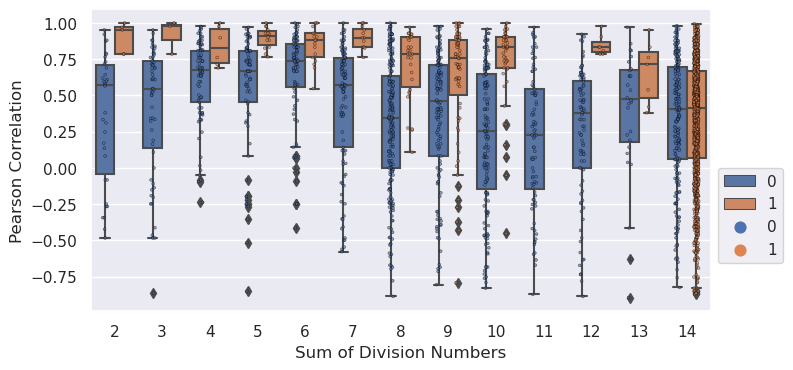

In [452]:
# Selected Set of Clonal Genes
genes = ['CCL17', 'SELL', 'PRDM1', 'EBI3', 'FCER2', 'HOPX', 'HLA-DQB1', 'CD19']
data = addPearsonofGOIS(df, genes, divisions)

#data = data[data['DivisionSum'] < 100]
data = data[(data['DivisionSum'] < 100) & (data['DivisionSum'] > 1)]

clonal_data = data[data.ClonalBool == 1]
nonclonal_data = data[data.ClonalBool != 1]


downsamples = nonclonal_data.sample(n = clonal_data.shape[0])

_data = pd.concat([clonal_data, downsamples])

sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'Pearson_GeneList', hue = 'ClonalBool')

p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.6, edgecolor = 'black', linewidth=0.4, size=2, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Pearson Correlation')
print(genes)
save_figure(fig, "Selected_ClonalGenesBoxPlot")

['PRDM1', 'HOPX', 'MS4A1', 'FAM46C', 'CD38', 'ACTC1', 'ZFP57', 'CKAP4', 'CLEC2B', 'HIST1H3G', 'PDE4D', 'CEP128', 'PAX5', 'CITED2', 'IQGAP2', 'ALOX5', 'TCEAL7', 'SETBP1', 'ZFAT', 'TRAM2', 'SELPLG', 'AHNAK', 'E2F2', 'COTL1', 'MYH8', 'CFI', 'TP53INP1', 'TEX261', 'KCNN3', 'AC246787.2', 'DTX1', 'VRK3', 'IL13RA1', 'HIST1H2BC', 'KCTD10', 'CIITA', 'VPS35L']


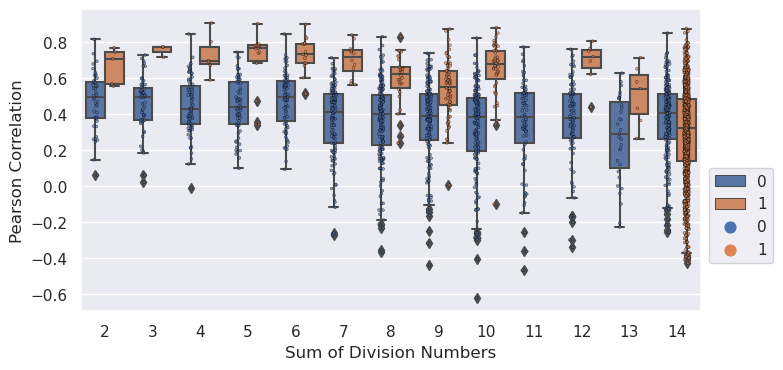

In [453]:
# Selected Set of Clonal Genes
genes = Clonal_Non_Environmental_Genes
data = addPearsonofGOIS(df, genes, divisions)

data = data[(data['DivisionSum'] < 100) & (data['DivisionSum'] > 1)]

clonal_data = data[data.ClonalBool == 1]
nonclonal_data = data[data.ClonalBool != 1]


downsamples = nonclonal_data.sample(n = clonal_data.shape[0])

_data = pd.concat([clonal_data, downsamples])

sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'Pearson_GeneList', hue = 'ClonalBool')

p_box = sns.boxplot(**params)
p = sns.stripplot(**params, alpha = 0.6, edgecolor = 'black', linewidth=0.4, size=2, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Pearson Correlation')
print(genes)
save_figure(fig, "OnlyClonalGenesBoxPlot")

## Jaccard

In [430]:
from sklearn.metrics import jaccard_score

In [431]:
from sklearn.utils import shuffle

In [432]:
_df = df.reset_index()

In [433]:
_df

,index,WASH7P,FO538757.1,MTND1P23,MTND2P28,ENSG00000276171,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,...,AC011043.1,ENSG00000277048,AL592183.1,ENSG00000274482,ENSG00000276736,AL354822.1,AC004556.1,AC233755.1,AC240274.1,RF00003-14
0,CTY_I8,0.000000,0.000000,1.346110,3.495827,0.000000,4.440911,1.899851,0.884273,5.427964,...,0.0,3.280236,0.00000,0.0,0.000000,0.000000,2.674261,0.000000,0.000000,0.0
1,MS_SISTER2_J10,1.427143,0.000000,0.000000,3.096114,0.720564,4.897875,2.351407,0.000000,5.391387,...,0.0,4.330037,0.00000,0.0,0.000000,0.000000,2.758636,0.720564,0.720564,0.0
2,NaiveBcellsplate2_20180629_D23,0.000000,1.987673,0.000000,4.438885,0.000000,3.394283,1.704557,0.000000,5.478321,...,0.0,7.536024,0.00000,0.0,1.029469,0.000000,0.000000,0.000000,0.641743,0.0
3,NaiveBcellsplate2_20180629_K4,0.000000,0.000000,0.000000,4.739808,0.000000,5.551127,1.308412,0.000000,5.871381,...,0.0,6.419940,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,NaiveBcellsplate2_20180629_P1,0.000000,0.000000,0.000000,3.009813,0.000000,4.150129,2.863846,0.000000,5.383169,...,0.0,1.541816,0.00000,0.0,0.000000,0.000000,0.000000,0.651422,3.766773,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,P1_5_23_19_D2_H8,0.000000,0.000000,0.000000,2.778814,0.000000,4.233376,2.778814,0.000000,5.738339,...,0.0,0.000000,3.35631,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1346,P1_5_23_19_D2_A19,0.000000,0.000000,0.408957,2.535336,0.000000,4.510133,3.287192,1.394134,5.842291,...,0.0,0.698380,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1347,P1_5_23_19_D2_M5,0.000000,0.000000,0.000000,1.791166,0.000000,3.849450,4.024652,0.000000,4.316785,...,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1348,P1_CTV_5_15_19_M19,0.000000,0.000000,0.000000,4.010050,0.000000,3.550867,0.000000,0.000000,4.449788,...,0.0,2.050103,0.00000,0.0,2.411714,0.000000,0.000000,0.000000,0.000000,0.0


In [434]:
np.random.shuffle(_df['index'])

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [435]:
_df.set_index(_df['index'], inplace=True)

In [436]:
_df = _df.iloc[:,1:]

In [437]:
#https://stackoverflow.com/questions/32322281/numpy-matrix-binarization-using-only-one-expression
def binarize_geneexpression(df, threshold, upper, lower):
    array = np.where(df>threshold, upper, lower)
    _df = pd.DataFrame(array, index=df.index, columns=df.columns)
    return _df

def calculatejaccardofGOIS(df, genelist, divisiondf):
    # binarize the data matrix: 
    df = df[genelist]
    df = binarize_geneexpression(df, 0, 1, 0)        
    # iterate thru comparison df
    jaccards = []
    for index, row in divisiondf.iterrows():
        cell1 = row['cell1']
        cell2 = row['cell2']
        jaccards.append(jaccard_score(df.loc[cell1].values, df.loc[cell2].values))
    
    jaccards = pd.Series(jaccards)
    
    return jaccards

## IgH Genes

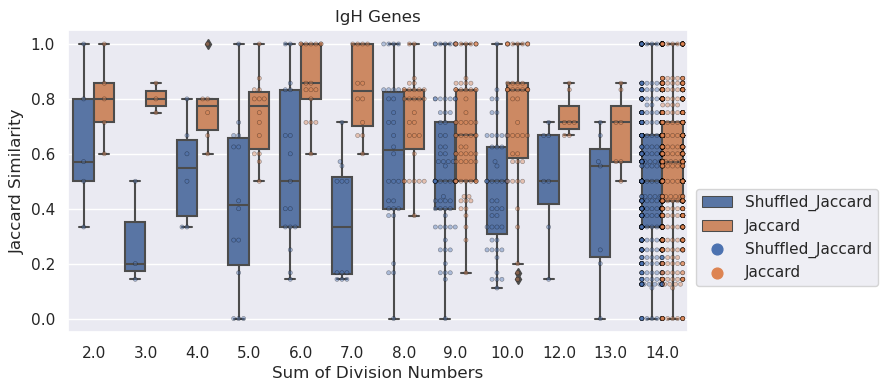

In [438]:
genes = IgH_genes
division_comp = divisions[divisions.ClonalBool == 1]
division_comp = division_comp[(division_comp['DivisionSum'] < 100) & (division_comp['DivisionSum'] > 1)]

data = calculatejaccardofGOIS(df, genes, division_comp)

shuffled_data = calculatejaccardofGOIS(_df, genes, division_comp)

_data = pd.DataFrame([division_comp['DivisionSum'].reset_index(drop=True), shuffled_data, data]).T

_data.columns = ['DivisionSum','Shuffled_Jaccard', 'Jaccard']

_data = _data.melt(id_vars = ['DivisionSum'])

_data = _data
sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'value', hue = 'variable')

p_box = sns.boxplot(**params)
p = sns.swarmplot(**params, alpha = 0.4, edgecolor = 'black', linewidth=0.4, size=3, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Jaccard Similarity')
plt.title('IgH Genes')
save_figure(fig, "IgH_Jaccard")

## Clonal Genes

In [447]:
clonal_tests.set_index('gene').loc[Clonal_Non_Environmental_Genes]

,Unnamed: 0,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,pvalue,corrected_pvalue
gene,,,,,,,,,,
PRDM1,3496,184,103872.0,True,4.534521,8.429470,2.034451,0.0,5.450439e-17,5.449894e-13
HOPX,2450,825,541174.0,True,5.648210,7.300493,0.542865,0.0,1.145103e-13,1.144988e-09
MS4A1,5431,1310,3465824.0,True,7.792882,8.471290,1.915214,0.0,9.177272e-12,9.176355e-08
FAM46C,525,316,129908.0,True,4.674635,7.968009,1.510107,0.0,1.183151e-11,1.183033e-07
CD38,2379,150,43750.0,True,3.421955,6.837884,0.266719,0.0,6.979474e-11,6.978776e-07
ACTC1,7296,127,57820.0,True,3.835708,7.432677,0.885675,0.0,1.049675e-09,1.049570e-05
ZFP57,3248,161,14796.0,True,2.383175,5.850508,-0.297057,0.0,5.428076e-09,5.427533e-05
CKAP4,6556,118,13464.0,True,2.564727,7.007147,0.744806,0.0,5.619327e-09,5.618765e-05
CLEC2B,6207,478,67160.0,True,4.050361,7.357823,0.781040,0.0,6.644239e-09,6.643575e-05


In [444]:
clonal_tests.gene.loc[Clonal_Non_Environmental_Genes]

KeyError: "None of [Index(['PRDM1', 'HOPX', 'MS4A1', 'FAM46C', 'CD38', 'ACTC1', 'ZFP57', 'CKAP4', 'CLEC2B', 'HIST1H3G',\n       'PDE4D', 'CEP128', 'PAX5', 'CITED2', 'IQGAP2', 'ALOX5', 'TCEAL7', 'SETBP1', 'ZFAT', 'TRAM2',\n       'SELPLG', 'AHNAK', 'E2F2', 'COTL1', 'MYH8', 'CFI', 'TP53INP1', 'TEX261', 'KCNN3',\n       'AC246787.2', 'DTX1', 'VRK3', 'IL13RA1', 'HIST1H2BC', 'KCTD10', 'CIITA', 'VPS35L'],\n      dtype='object')] are in the [index]"

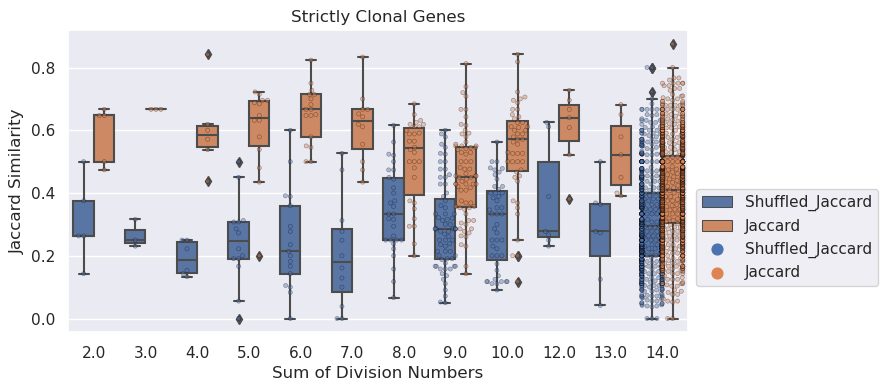

In [448]:
genes = Clonal_Non_Environmental_Genes
division_comp = divisions[divisions.ClonalBool == 1]
division_comp = division_comp[(division_comp['DivisionSum'] < 100) & (division_comp['DivisionSum'] > 1)]

data = calculatejaccardofGOIS(df, genes, division_comp)

shuffled_data = calculatejaccardofGOIS(_df, genes, division_comp)

_data = pd.DataFrame([division_comp['DivisionSum'].reset_index(drop=True), shuffled_data, data]).T

_data.columns = ['DivisionSum','Shuffled_Jaccard', 'Jaccard']

_data = _data.melt(id_vars = ['DivisionSum'])

_data = _data
sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'value', hue = 'variable')

p_box = sns.boxplot(**params)
p = sns.swarmplot(**params, alpha = 0.4, edgecolor = 'black', linewidth=0.4, size=3, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Jaccard Similarity')
plt.title('Strictly Clonal Genes')
save_figure(fig, "StrictlyClonalGenesJaccard")


### Non_Clonal Genes

In [440]:
clonal_tests[clonal_tests.corrected_pvalue < 0.01]

,Unnamed: 0,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,gene,pvalue,corrected_pvalue
0,9682,588,1086626.0,True,6.340825,10.080306,3.784099,0.0,IGLC3,2.220307e-31,2.220085e-27
1,9676,115,647000.0,True,6.040084,9.787668,3.438591,0.0,IGLV3-21,2.352851e-30,2.352616e-26
2,9681,690,657556.0,True,6.079558,8.290209,1.695154,0.0,IGLC2,1.066038e-29,1.065931e-25
3,1306,861,195231.0,True,4.662151,7.096407,0.519733,0.0,IGKC,9.915628e-27,9.914636e-23
4,1313,166,280429.0,True,5.018114,8.508896,2.124700,0.0,IGKV3-20,1.100393e-23,1.100283e-19
...,...,...,...,...,...,...,...,...,...,...,...
388,6695,825,129927.0,True,4.546215,7.051632,0.468856,0.0,ANKLE2,9.151555e-07,9.150639e-03
389,4878,950,248788.0,True,5.146195,6.908022,0.292166,0.0,SMARCA2,9.361351e-07,9.360415e-03
390,655,857,149069.0,True,4.628125,6.449975,-0.214787,0.0,SLC50A1,9.565564e-07,9.564608e-03
391,120,673,126558.0,True,4.385147,6.573646,-0.048891,0.0,AKR7A2,9.694430e-07,9.693460e-03


Text(0, 0.5, 'Jaccard')

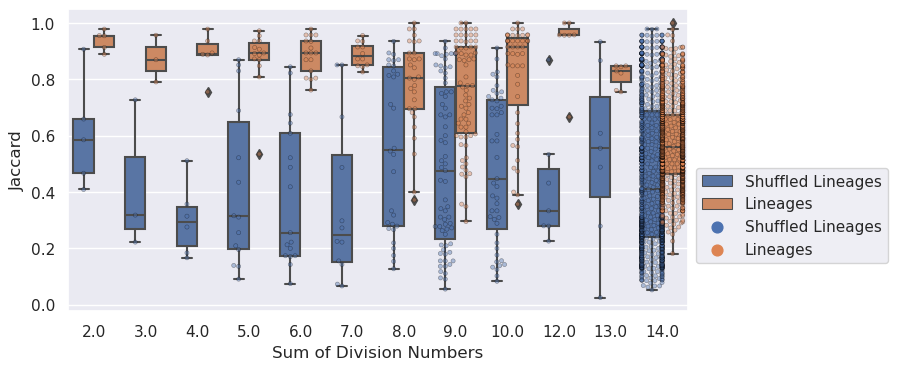

In [441]:
non_clonal = list(clonal_tests[(clonal_tests.corrected_pvalue > 0.2) 
                               & (clonal_tests.means > 4)
                              ].gene[:len(clonal_nonIg)])

genes = non_clonal
division_comp = divisions[divisions.ClonalBool == 1]
division_comp = division_comp[(division_comp['DivisionSum'] < 100) & (division_comp['DivisionSum'] > 1)]

data = calculatejaccardofGOIS(df, genes, division_comp)

shuffled_data = calculatejaccardofGOIS(_df, genes, division_comp)

_data = pd.DataFrame([division_comp['DivisionSum'].reset_index(drop=True), shuffled_data, data]).T

_data.columns = ['DivisionSum','Shuffled Lineages', 'Lineages']

_data = _data.melt(id_vars = ['DivisionSum'])

_data = _data
sns.set(rc={'figure.figsize':(8, 4)})

fig , ax = plt.subplots(1,1)
params = dict(data = _data, x = 'DivisionSum', y = 'value', hue = 'variable')

p_box = sns.boxplot(**params)
p = sns.swarmplot(**params, alpha = 0.4, edgecolor = 'black', linewidth=0.4, size=3, dodge = True)
ax.legend(bbox_to_anchor=(1, 0.5))
plt.xlabel('Sum of Division Numbers')
plt.ylabel('Jaccard')
#save_figure(fig, "OnlyClonalGenesBoxPlot")